In [28]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from physics_equations import specific_humidity_from_rh
import profiles_and_cloud_heights as profiles
from constants import g,alpha
import interpolation_lcl as interp
from autoconversion_rate import thresh
import autoconversion_rate as ar
import GB84_eqs # import f as flux, rho_m,flux_2
import updraft_emmanuel
#from updraft_emmanuel import w_parcel 
import new_rainfall_scheme as nr
import top_outflow as outflow

## Loading the data

In [209]:
#time to check
slice_str = "2024-07-16T00:00:00, 2024-07-16T23:59:00"
slice_tuple = tuple(slice_str.split(", "))


In [210]:
data_era = xr.open_mfdataset(r'..\data\ERA5\profiles\*.nc')
time_dim = 'valid_time'
data_era_10min = data_era.resample({time_dim: '10min'}).interpolate('linear')
data_surface = xr.open_dataset(r'..\data\Cabauw_cesar_surface\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')


In [211]:
data_era = data_era_10min.sel(valid_time=slice(*slice_tuple))
data_era = data_era.sel(latitude=51.96,longitude=4.9,method='nearest')
data_era = data_era.sortby('pressure_level', ascending=False)
data_era = data_era.sel(pressure_level=slice(1e5,200))
time = data_era_10min.sel(valid_time=slice(*slice_tuple)).valid_time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)
data_surface = data_surface.sel(time=time, method='nearest')

In [212]:
dt_seconds

array([600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.])

In [213]:
my_temp = data_era.t.values
p = data_era.pressure_level*100
q_v = data_era.q.values
Z = data_era.z.values/g

In [214]:
my_temp_surface = data_surface.TA002.values
p_surface = data_surface.P0.values*100
T_d = data_surface.TD002.values
Z_surface = 2*np.ones(len(p_surface))  

In [215]:
def relative_humidity(t_air, t_dew):
    """
    t_air and t_dew in Celsius
    Returns RH in %
    """
    rh = 100 * (np.exp((17.67 * t_dew) / (t_dew + 243.5)) / 
                np.exp((17.67 * t_air) / (t_air + 243.5)))
    return rh

In [216]:
T_air = np.concatenate([my_temp_surface.reshape(len(my_temp_surface), 1), my_temp], 1)
p_surf = p_surface #[Pa]
p_air = np.tile(p.values,(len(p_surf),1))
p_air = np.concatenate([p_surf.reshape(len(p_surf), 1), p_air], 1) #[Pa]
Z = np.concatenate([Z_surface.reshape(len(Z_surface), 1), Z], 1)

RH_surf = relative_humidity(my_temp_surface, T_d)
q_v_surf = specific_humidity_from_rh(my_temp_surface,RH_surf/100, p_surf)
q_v_air = np.concatenate([q_v_surf.reshape(len(q_v_surf), 1), q_v], 1) 

#### Environmental profiles and inputs

T_air = data_era.temperature.values
p_air = data_era.pressure.values
Z = data_era.height.values
T_d = data_era.dew_point_temperature.values
q_v_air = data_era.specific_humidity.values

#### Parsivel rainfall data

In [217]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


## Running the model

### Parcel Profiles

In [218]:
rows = T_air.shape[0]
cols = T_air.shape[1]

In [219]:
T_arr = np.zeros((T_air.shape))
p_s = np.zeros(rows)    #cloud base pressure (time)
T_s = np.zeros(rows)    #cloud base temperature (time)
lcl_index = np.zeros(rows) #lcl index (time)

## empty arrays for storing the interpolated profiles (time, height+1)
temp_parcel = np.zeros((rows,cols+1))  # new parcel temperature (time, height+1)
my_temp_new = np.zeros((rows,cols+1))   # new temperature profile (time, height+1)
p_new = np.zeros((rows,cols+1))         # new pressure profile (time, height+1)
q_v_new = np.zeros((rows,cols+1))       # new specific humidity profile (time, height+1)
Z_new = np.zeros((rows,cols+1))         # new height profile (time, height+1)

## empty arrays for storing the outputs
T_v_moist = np.zeros((rows,cols+1))
q_v_parcel = np.zeros((rows,cols+1))
Z_b = np.zeros(rows)


In [220]:
#import profiles_and_cloud_heights as profiles
#import interpolation_lcl as interp

theta_type = 'theta_e_reversible'       #choose which approach to follow for the conserved potential temperature

for i in range(0,T_air.shape[0]):
    print(i)
    #calculating the profiles
    T_arr[i,:],lcl_index[i],p_s[i],T_s[i] = profiles.calculate_parcel_Temp_profile(T_air[i,0],p_air[i,0],T_d[i],p_air[i],theta_type=theta_type)

    #interpolation at the lcl level
    temp_parcel[i], p_new[i], Z_new[i], lcl_index[i], my_temp_new[i], q_v_new[i] = interp.insert_lcl_values(T_arr[i,:],p_air[i],Z[i],int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])

    #calculating the virtual temperature profile of the parcel
    T_v_moist[i,:],q_v_parcel[i,:] = profiles.calculate_parcel_T_v_profile(T_d[i],p_new[i,0],p_new[i],temp_parcel[i,:],int(lcl_index[i]),theta_type=theta_type)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17


18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143


In [221]:
T_v_env = my_temp_new*(1+0.61*q_v_new)

### Cloud Heights

In [222]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc_level(
        T_v_moist[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

In [223]:
#empty arrays for storing the outputs
Z_c = np.zeros(rows)
Z_t = np.zeros(rows)
p_t = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c[i],Z_t[i],p_t[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist[i],T_v_env[i],temp_parcel[i])

### Updraft speed

In [224]:
import updraft_emmanuel

w_parcel_max = np.zeros(rows)

for i in range(0,rows):
    print(i)
    if Z_t[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t[i] - Z_new[i]) <= 0)
    #print(top_index,int(LFC_index[i,1]))
    w_parcel_max[i],CAPE = updraft_emmanuel.calculate_parcel_updraft_velocity(p_new[i],T_v_moist[i],T_v_env[i],LFC_index[i,1],p_t[i],top_index)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
[0.01301945]
42
[0.00831164 0.02666825]
43
[0.00993855]
44
[0.00904131 0.02666825]
45
[0.00932907 0.02666825 0.02739897 0.02817088 0.02898754 0.02985296
 0.03077166 0.0317487  0.03278982 0.06899287 0.07410797]
46
[0.00924418 0.02666825 0.02739897 0.02817088 0.02898754 0.02985296
 0.03077166 0.0317487  0.03278982 0.06899287 0.07410797]
47
[0.00459797 0.02666825 0.02739897 0.02817088 0.02898754 0.02985296
 0.03077166 0.0317487  0.03278982 0.06899287 0.07410797]
48
[0.00400968 0.02666825 0.02739897 0.02817088 0.02898754 0.02985296
 0.03077166 0.0317487  0.03278982 0.06899287 0.07410797]
49
[0.00986826 0.02666825 0.02739897 0.02817088 0.02898754 0.02985296
 0.03077166 0.0317487  0.03278982 0.06899287 0.07410797]
50
[0.00537717 0.02666825 0.02739897 0.02817088 0.02898754 0.02985296
 0.03077166 0.0317487  0.03278982 0.06899287 0.07410797]
51
[0.0032433]
52
[0.00122167 0.0266682

### State calculation and update

In [225]:
#import autoconversion_rate as ar
#from GB84_eqs import f as flux, rho_m
#import top_outflow as outflow

#empty arrays for storing condensation flux and state values
f_arr = np.zeros(rows)
X =np.zeros(rows)


for i in range(0,rows):
    print(i)
    if Z_t[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t[i] - Z_new[i]) <= 0)

    w_avg = w_parcel_max[i]/2
    rho = GB84_eqs.rho_m(T_s[i],my_temp_new[i,min(top_index,cols-1)],p_s[i],p_t[i])

    if w_parcel_max[i] == 0:
        # no convection == no flux
        f_arr[i] = 0
    else:
        f_arr[i] = GB84_eqs.calculate_liquid_water_flux(T_d[i],p_new[i,0],p_t[i],my_temp_new[i,min(top_index,cols-1)],rho,w_avg)

    if i<rows-1:
        #if X[i]/Z_c[i] > 2.5e-3:        #capping the X values so that they don't abnormally high
            #X[i] = 2.5e-3*Z_c[i]

    #state update
        X[i+1] = X[i] +f_arr[i]*dt_seconds[i] - ar.cloud_water_autoconoversion_rate(X[i],Z_c[i],thresh)*dt_seconds[i] - outflow.calculate_water_top_outflow(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i]
        #print(outflow.O_t(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i])
        X[i+1] = max(0,X[i+1])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143


In [226]:
index = np.where(f_arr>0)
np.mean(f_arr)

0.02731779073253435

In [227]:
np.mean(Z_c[index])

3388.485550948529

#### Rainfall rates

In [228]:
#import autoconversion_rate as ar
#import new_rainfall_scheme as nr

# empty arrays for storing the rainfall rates and the size distribution parameters

R = np.zeros(rows)  #rainfall rate at the cloud base
P = np.zeros(rows)  #precipitation rate at the surface

lambda_arr = np.zeros(rows)     #slope parameter of Gamma distribution
mu_result_arr = np.zeros(rows)  #shape parameter of Gamma distribution
Dc_arr = np.zeros(rows)         #critical diameter for evaporation


for i in range(0,rows):
    R[i] = ar.cloud_water_autoconoversion_rate(X[i],Z_c[i],thresh)
    if R[i]<=1e-6:
        P[i] = 0
    else:
        print(i)
        Lambda_result = nr.solve_lambda_mu_dependent(R[i], alpha, w_parcel_max[i]/2*100)
        mu_result = nr.mu_from_lambda(Lambda_result)
        print(mu_result,Lambda_result)
        D_critical = ar.critical_diameter(my_temp_new[i,0], p_new[i,0], T_d[i], Z_new[i,int(lcl_index[i])], Z_c[i],w_parcel_max[i]/2*100).calculate_evaporation_critical_diameter()
        P[i] = nr.ground_precipitation_rate(R[i], mu_result, Lambda_result, D_critical*100,w_parcel_max[i]/2*100,alpha)

42
15.084958214222482 186.2513486955189
43
10.141938020914472 118.16018825183906
46
-0.3476855732476991 13.50790251961251
47
-0.6371425726438531 11.041753322215431
48
-0.8515199870384142 9.225875495016599
50
-0.5801453624622834 11.52605633537608
53
-1.1177767212036673 6.982893714230932
55
-1.0396659988101131 7.639504752245844
57
-1.1941500034500474 6.342006294847269
59
-1.2768199885340747 5.649519729377958
61
-0.9452381109679189 8.434833601767536
62
-0.24216555045645682 14.411072474201255
63
1.4109897209678233 28.864779918613543
65
-1.3984100054062734 4.633345900003121
67
-1.3363470629904008 5.151684363516966
68
-1.3556041732677298 4.9907756085762225
69
-1.3144771220921259 5.334509451625653
73
-0.9405066766487313 8.47472951194872
74
-0.5211869230752186 12.02769623410355
75
0.8220771257307631 23.648450094213732
76
3.7082996076585912 50.00284528921081
77
7.07088963146128 83.65757670044326
78
9.038101811920003 105.25783864130439
80
-1.3769567358597241 4.812438536580497
82
-1.4465243310421

In [229]:
dt_seconds

array([600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.,
       600., 600., 600., 600., 600., 600., 600., 600., 600., 600., 600.])

## Visualizing the outputs

#### Rainfall rate

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

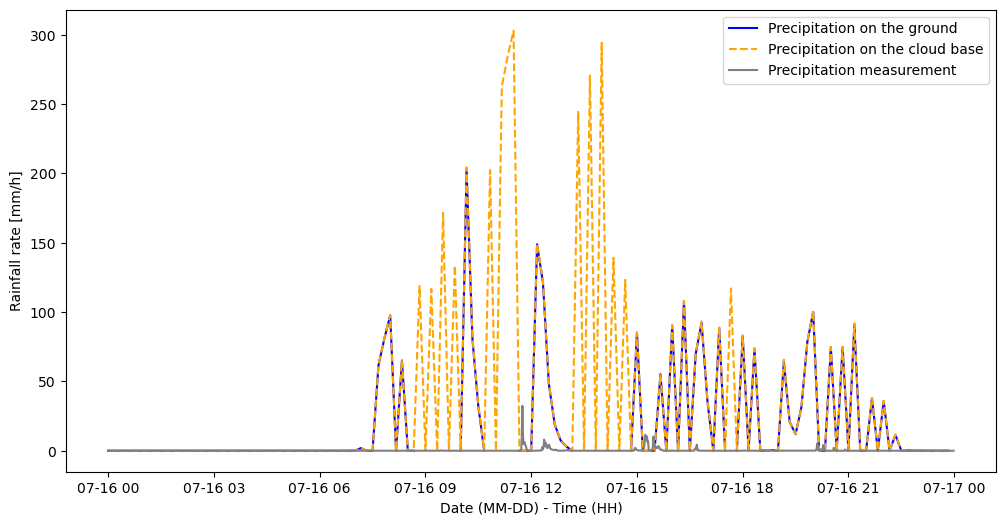

In [230]:
plt.figure(figsize=(12,6))
plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
plt.plot(time,R*3600,color='orange',linestyle='--',label='Precipitation on the cloud base')
plt.plot(rain_rate.time,rain_rate,color='gray',label='Precipitation measurement')
plt.legend()
plt.ylabel('Rainfall rate [mm/h]')
plt.xlabel('Date (MM-DD) - Time (HH)')

#### Virtual Temperature profiles at different times

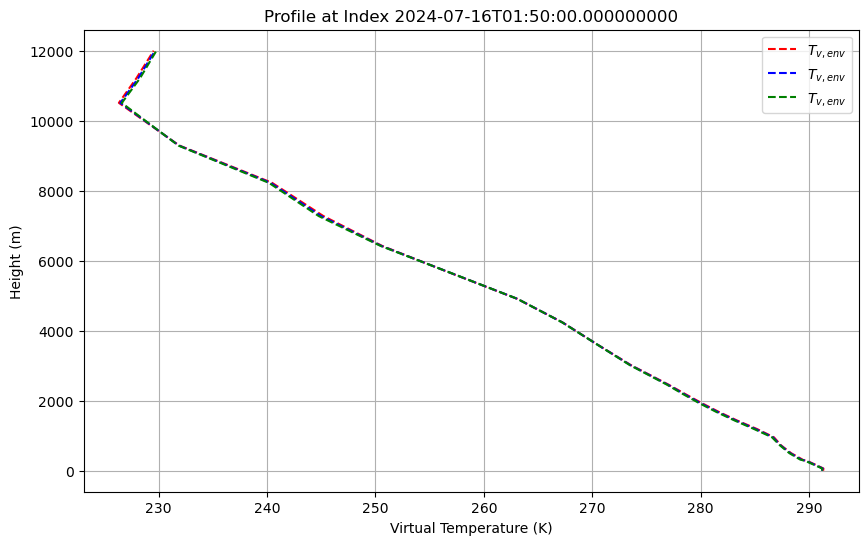

In [231]:
index_2 = 11
fig,ax2 = plt.subplots(figsize=(10,6))
ax2.plot(my_temp_new[index_2+17] * (1 + 0.61 * q_v_new[index_2+17]), Z_new[index_2+17], 
        label='$T_{v,env}$', color='red', linestyle='--')
ax2.plot(my_temp_new[index_2+18] * (1 + 0.61 * q_v_new[index_2+18]), Z_new[index_2+18], 
        label='$T_{v,env}$', color='blue', linestyle='--')
ax2.plot(my_temp_new[index_2+19] * (1 + 0.61 * q_v_new[index_2+19]), Z_new[index_2+19], 
        label='$T_{v,env}$', color='green', linestyle='--')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.set_ylabel('Height (m)')
ax2.set_title(f'Profile at Index {time[index_2].values}')
ax2.legend()
ax2.grid(True)

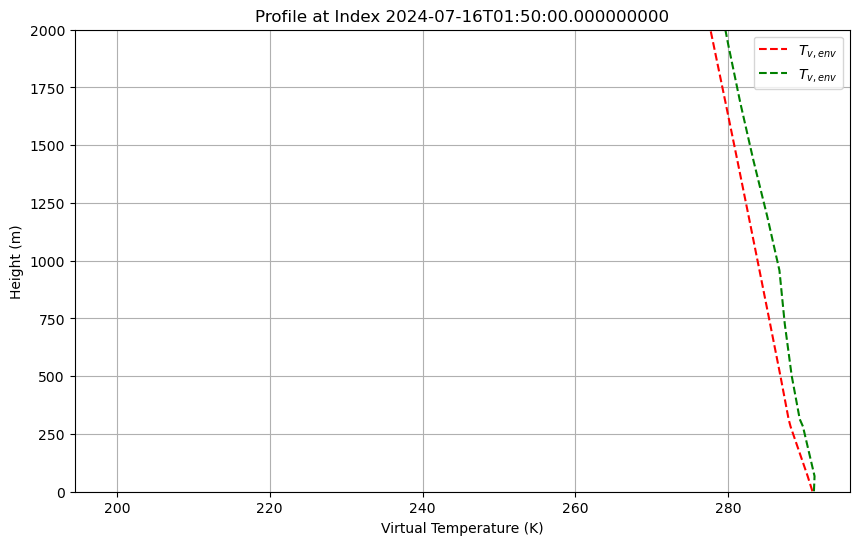

In [232]:
index_2 = 11
fig,ax2 = plt.subplots(figsize=(10,6))
ax2.plot(T_v_moist[index_2+18], Z_new[index_2+18], 
        label='$T_{v,env}$', color='red', linestyle='--')
#ax2.plot(T_v_moist[index_2+18], Z_new[index_2+18], 
        #label='$T_{v,env}$', color='blue', linestyle='--')
#ax2.plot(T_v_moist[index_2+19], Z_new[index_2+19], 
        #label='$T_{v,env}$', color='green', linestyle='--')
ax2.plot(my_temp_new[index_2+18] * (1 + 0.61 * q_v_new[index_2+18]), Z_new[index_2+18], 
        label='$T_{v,env}$', color='green', linestyle='--')
#ax2.plot(my_temp_new[index_2+18] * (1 + 0.61 * q_v_new[index_2+18]), Z_new[index_2+18], label='$T_{v,env}$', color='blue', linestyle='--')
#ax2.plot(my_temp_new[index_2+19] * (1 + 0.61 * q_v_new[index_2+19]), Z_new[index_2+19],label='$T_{v,env}$', color='green', linestyle='--')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.set_ylabel('Height (m)')
plt.ylim(0,2000)
ax2.set_title(f'Profile at Index {time[index_2].values}')
ax2.legend()
ax2.grid(True)

In [233]:
Z_t[index_2+17:index_2+21]

array([0., 0., 0., 0.])

In [234]:
my_temp_new[index_2+17:index_2+21,0]

array([289.35998535, 289.26000977, 289.27999878, 289.13998413])

In [235]:
q_v_air[index_2+17:index_2+21,0]

array([0.01105545, 0.01097638, 0.01097812, 0.01089233])

In [236]:
w_parcel_max[index_2+17:index_2+21]

array([0., 0., 0., 0.])

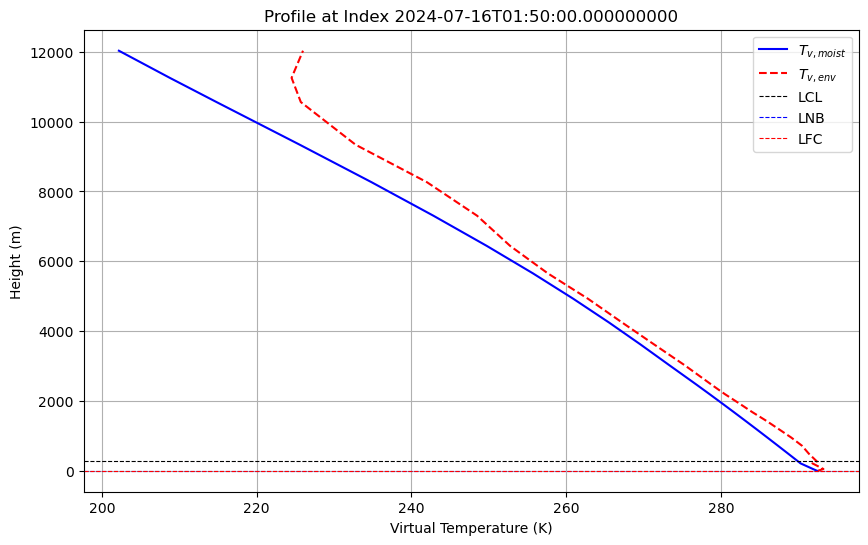

In [237]:
index_2 = 11
fig,ax2 = plt.subplots(figsize=(10,6))
ax2.plot(T_v_moist[index_2], Z_new[index_2], label='$T_{v,moist}$', color='blue')
ax2.plot(my_temp_new[index_2] * (1 + 0.61 * q_v_new[index_2]), Z_new[index_2], 
        label='$T_{v,env}$', color='red', linestyle='--')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.axhline(y=Z[index_2,int(lcl_index[index_2])], color='black', linestyle='--',linewidth='0.8',label='LCL')
ax2.axhline(y=Z_t[index_2], color='blue', linestyle='--',linewidth='0.8',label='LNB')
ax2.axhline(y=Z[index_2,int(LFC_index[index_2,1])], color='red', linestyle='--',linewidth='0.8',label='LFC')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.set_ylabel('Height (m)')
ax2.set_title(f'Profile at Index {time[index_2].values}')
ax2.legend()
ax2.grid(True)

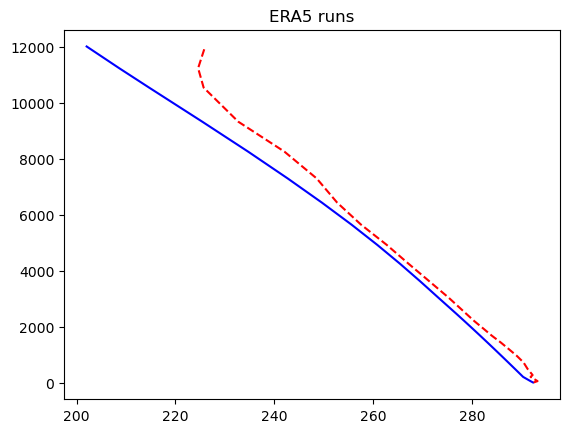

In [238]:
index = int(np.where(time == np.datetime64('2024-07-16T02:00:00'))[0][0])
plt.title('ERA5 runs')
plt.plot(T_v_moist[index], Z_new[index], label='$T_{v,moist}$', color='blue')
plt.plot(T_v_env[index], Z_new[index], label='$T_{v,env}$', color='red', linestyle='--')

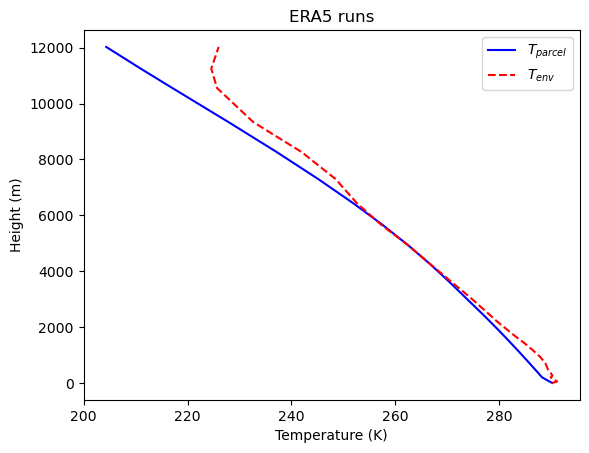

In [239]:
plt.title('ERA5 runs')
plt.plot(temp_parcel[index], Z_new[index], label='$T_{parcel}$', color='blue')
plt.plot(my_temp_new[index], Z_new[index], label='$T_{env}$', color='red', linestyle='--')
plt.xlabel('Temperature (K)')
plt.ylabel('Height (m)')
plt.legend()

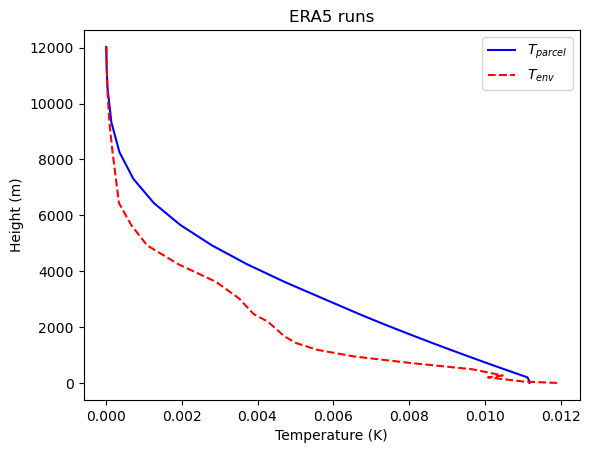

In [240]:
plt.title('ERA5 runs')
plt.plot(q_v_parcel[index], Z_new[index], label='$T_{parcel}$', color='blue')
plt.plot(q_v_new[index], Z_new[index], label='$T_{env}$', color='red', linestyle='--')
plt.xlabel('Temperature (K)')
plt.ylabel('Height (m)')
plt.legend()

In [241]:
np.savez('parcel_data.npz',
         T_v_moist= T_v_moist[index],
         T_v_env=T_v_env[index],
         temp_parcel=temp_parcel[index],
         temp_env=my_temp_new[index],
         q_v_parcel=q_v_parcel[index],
         q_v_env=q_v_new[index],
         Z=Z_new[index])

In [242]:
time[index]

<xarray.DataArray 'valid_time' ()> Size: 8B
array('2024-07-16T02:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    number      int64 8B 0
    valid_time  datetime64[ns] 8B 2024-07-16T02:00:00
Attributes:
    long_name:      time
    standard_name:  time

In [243]:
my_temp_new[index,0]
q_v_air[2,0]

0.011796494014561176

#### Cloud top and base

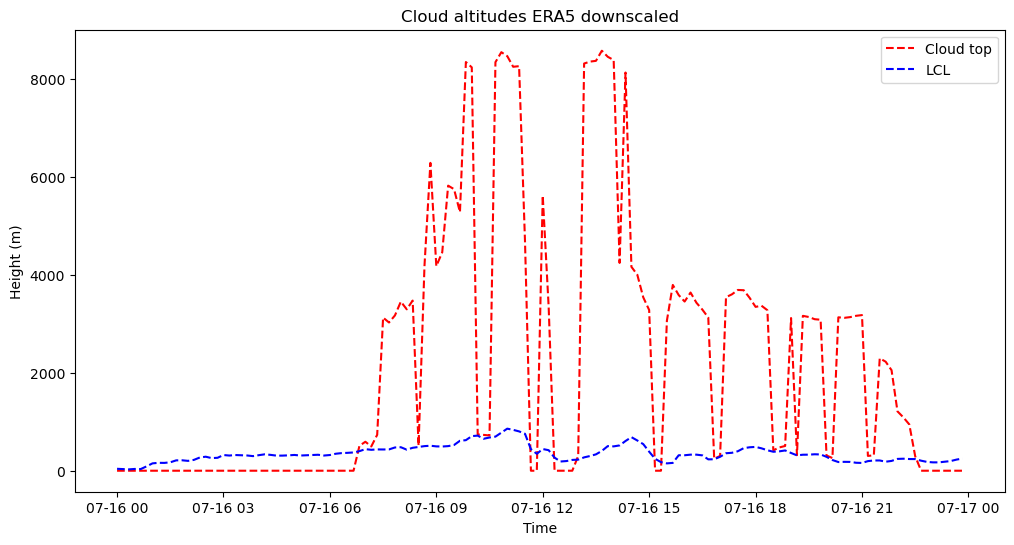

In [249]:

plt.figure(figsize=(12,6))
plt.title('Cloud altitudes ERA5 downscaled')
plt.plot(time,Z_t,color='red',linestyle='--',label='Cloud top')
plt.plot(time,Z_new[np.arange(Z_new.shape[0]),lcl_index.astype(int)],color='blue',linestyle='--',label='LCL')
plt.ylabel('Height (m)')
plt.xlabel('Time')
plt.legend()

#### Updraft velocity

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

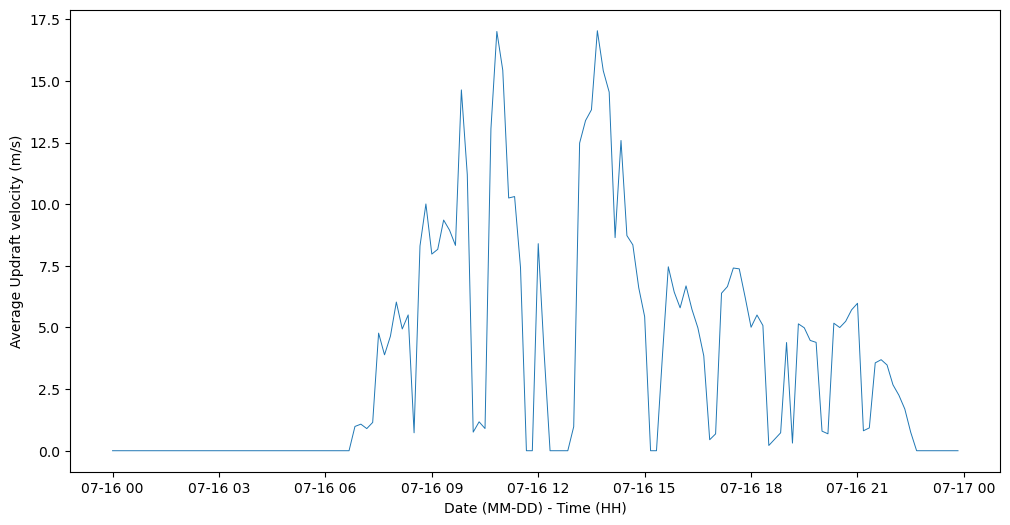

In [245]:
plt.figure(figsize=(12,6))
plt.plot(time,w_parcel_max/2,linewidth=0.7)
plt.ylabel('Average Updraft velocity (m/s)')
plt.xlabel(('Date (MM-DD) - Time (HH)'))

#### LWC and LWP(state)

(0.0, 10.0)

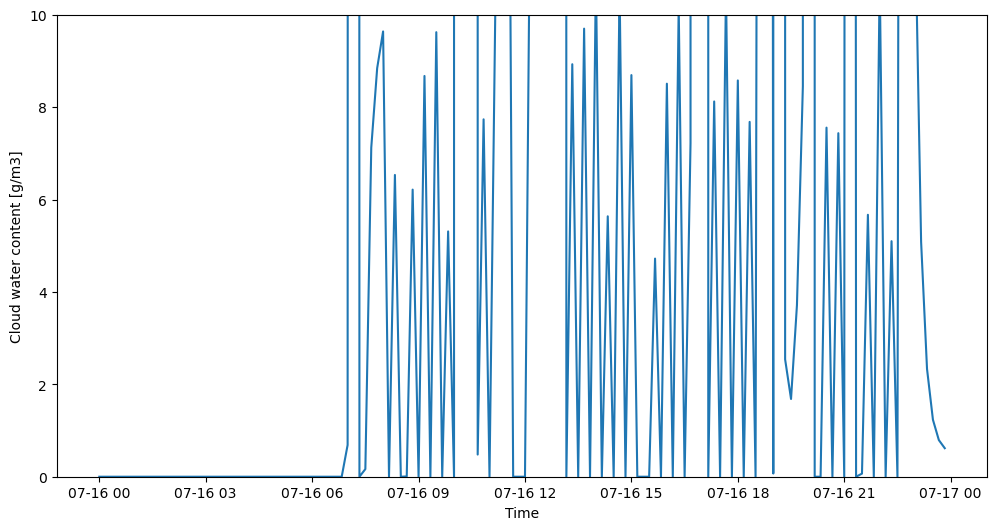

In [246]:
plt.figure(figsize=(12,6))
plt.plot(time,X/Z_c*1000)
plt.ylabel('Cloud water content [g/m3]')
plt.xlabel('Time')
plt.ylim(0,10)

Text(0, 0.5, 'Cloud water content [kg/m2]')

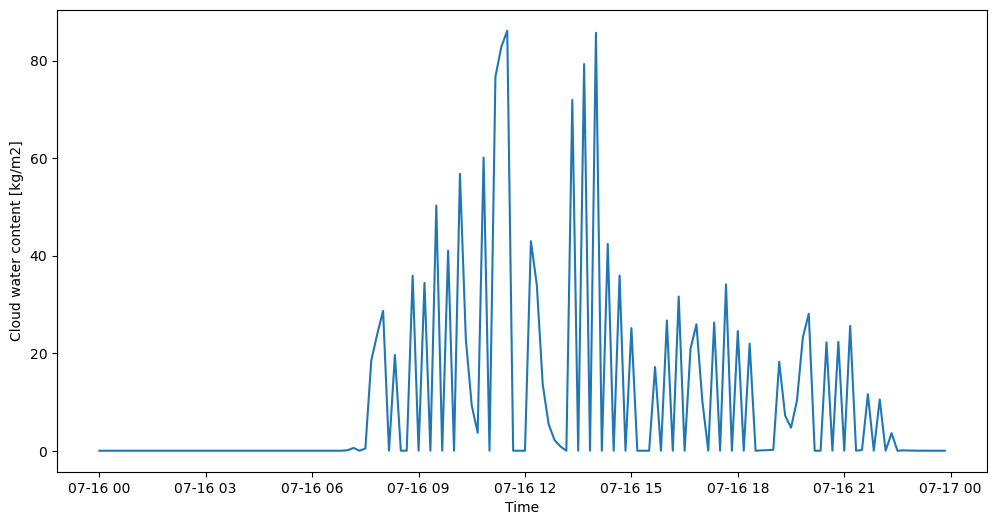

In [247]:
plt.figure(figsize=(12,6))
plt.plot(time,X)
plt.xlabel('Time')
plt.ylabel('Cloud water content [kg/m2]')

#### Size distribution

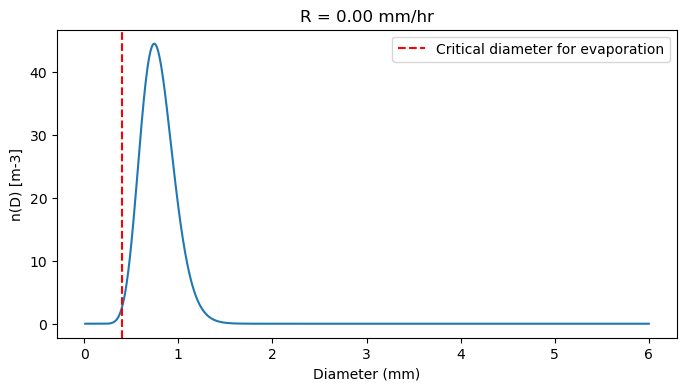

In [248]:
D = np.linspace(0.001,0.6,1000)
N = 6e4 * np.exp(3.2 * mu_result)* D**(mu_result)*np.exp(-Lambda_result*D)#plt.ylim(0,100)

plt.figure(figsize=(8,4))
plt.title(f'R = {R[i] * 3600:.2f} mm/hr')
plt.plot(D*10,N)
plt.axvline(x=D_critical*1000,color='r',linestyle='--',label='Critical diameter for evaporation')
plt.xlabel('Diameter (mm)')
plt.ylabel('n(D) [m-3]')
plt.legend()